In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [6]:
data1 = pd.read_csv('data/synthetic_mobile_money_transaction_dataset.csv')
data1

# MomTSim : https://data.mendeley.com/datasets/zhj366m53p/1

,step,transactionType,amount,initiator,oldBalInitiator,newBalInitiator,recipient,oldBalRecipient,newBalRecipient,isFraud
0,0,TRANSFER,19824.96,4537027967639631,187712.18,167887.22,4875702729424478,8.31,19833.27,1
1,0,PAYMENT,598.97,4296267625767470,8.92,8.92,25-0000401,0.00,0.00,0
2,0,PAYMENT,545.85,4178224023847746,93.60,-452.25,13-0001587,0.00,545.85,0
3,0,TRANSFER,19847.01,4178224023847746,-452.25,-20299.26,4096920916696293,4011.72,23858.74,1
4,0,PAYMENT,546.89,4779013371563747,159148.76,158601.88,75-0003564,0.00,546.89,0
...,...,...,...,...,...,...,...,...,...,...
1720176,143,DEPOSIT,189001.06,4663743651962693,3153757.97,3342759.03,72-0003211,132293.79,132293.79,0
1720177,143,PAYMENT,700.80,4823452294389366,4949410.71,4948709.91,23-0002032,143754.84,144455.64,0
1720178,143,TRANSFER,83799.76,4823452294389366,4948709.91,4864910.15,4271888998665790,16908.07,100707.82,1
1720179,143,PAYMENT,599.78,4118786864093625,3739281.18,3738681.40,35-0003267,109393.87,109993.65,0


In [7]:
data2 = pd.read_csv('data/Synthetic_Financial_datasets_log.csv')
data2

# PaySim : https://www.kaggle.com/datasets/sriharshaeedala/financial-fraud-detection-dataset?resource=download

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [8]:
# Data Cleaning and Renaming Columns for Consistency
data2 = data2.drop(columns=['isFlaggedFraud'])
data2.rename(columns={'type': 'transactionType', 'nameOrig': 'initiator','oldbalanceOrg': 'oldBalInitiator', 'newbalanceOrig': 'newBalInitiator','nameDest': 'recipient', 'oldbalanceDest': 'oldBalRecipient','newbalanceDest': 'newBalRecipient'}, inplace=True)
data2

,step,transactionType,amount,initiator,oldBalInitiator,newBalInitiator,recipient,oldBalRecipient,newBalRecipient,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0
...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1


In [9]:
# Merging Datasets
data2 = data2.drop(columns=['step'])
data1 = data1.drop(columns=['step'])
dataset = pd.concat([data1, data2], ignore_index=True)
dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8082801 entries, 0 to 8082800
Data columns (total 9 columns):
 #   Column           Dtype  
---  ------           -----  
 0   transactionType  object 
 1   amount           float64
 2   initiator        object 
 3   oldBalInitiator  float64
 4   newBalInitiator  float64
 5   recipient        object 
 6   oldBalRecipient  float64
 7   newBalRecipient  float64
 8   isFraud          int64  
dtypes: float64(5), int64(1), object(3)
memory usage: 555.0+ MB


In [10]:
dataset['initiator'] = dataset['initiator'].astype(str)
dataset['recipient'] = dataset['recipient'].astype(str)

In [11]:
# Checking for Missing Values
dataset.isna().sum()

transactionType    0
amount             0
initiator          0
oldBalInitiator    0
newBalInitiator    0
recipient          0
oldBalRecipient    0
newBalRecipient    0
isFraud            0
dtype: int64

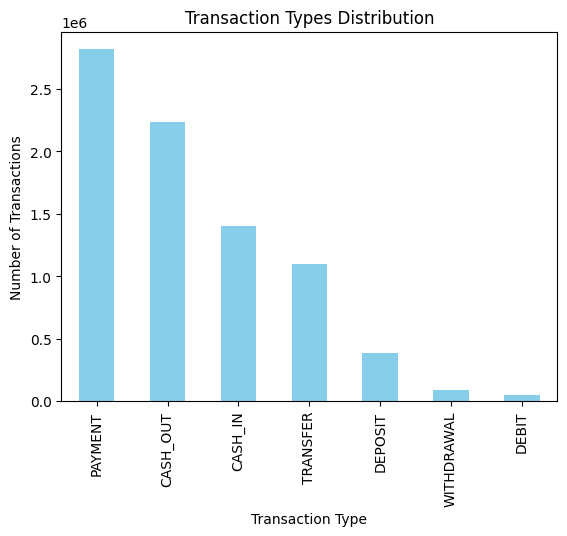

In [12]:
# Visualizing the Distribution of Transaction Types
count_type = dataset['transactionType'].value_counts()
count_type.plot(kind='bar', color='skyblue')
plt.title('Transaction Types Distribution')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')
plt.show()

###### The graph shows that PAYMENT, CASH_OUT, CASH_IN, and TRANSFER dominate the transaction activity, with PAYMENT being the highest by a large margin. Lower-volume types like DEPOSIT, WITHDRAWAL, and especially DEBIT contribute only a small fraction of total transactions.

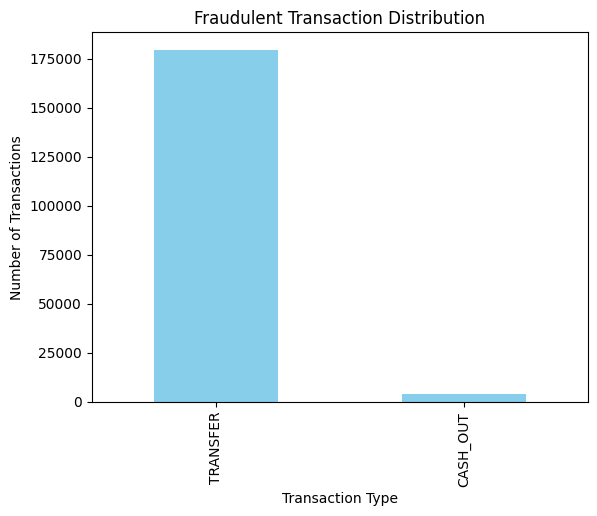

In [13]:
# Visualizing the Distribution of Fraudulent Transaction Types
count_type_fraud = dataset['transactionType'][dataset['isFraud']==1].value_counts()
count_type_fraud.plot(kind='bar', color='skyblue')
plt.title('Fraudulent Transaction Distribution')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')
plt.show()

###### The chart shows that fraudulent activity is overwhelmingly concentrated in TRANSFER transactions, with over 180,000 cases. CASH_OUT fraud is extremely low in comparison, showing only a small number of incidents.

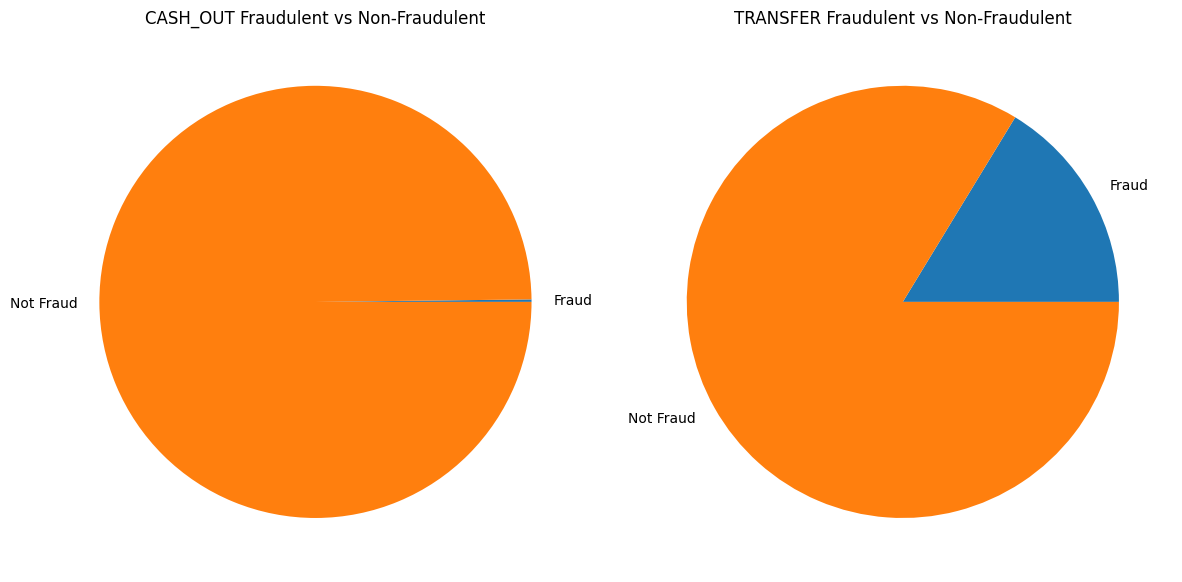

In [14]:
# ---- CASH_OUT ----
total_cash_out_fraud = dataset[(dataset['transactionType'] == 'CASH_OUT') & 
                               (dataset['isFraud'] == 1)].shape[0]

total_cash_out_not_fraud = dataset[(dataset['transactionType'] == 'CASH_OUT') & 
                                   (dataset['isFraud'] == 0)].shape[0]

cash_out_y = np.array([total_cash_out_fraud, total_cash_out_not_fraud])

# ---- TRANSFER ----
total_transfer_fraud = dataset[(dataset['transactionType'] == 'TRANSFER') & 
                               (dataset['isFraud'] == 1)].shape[0]

total_transfer_not_fraud = dataset[(dataset['transactionType'] == 'TRANSFER') & 
                                   (dataset['isFraud'] == 0)].shape[0]

transfer_y = np.array([total_transfer_fraud, total_transfer_not_fraud])

labels = ['Fraud', 'Not Fraud']

# ---- Side-by-side plots ----
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# CASH_OUT pie
axes[0].pie(cash_out_y, labels=labels)
axes[0].set_title('CASH_OUT Fraudulent vs Non-Fraudulent')

# TRANSFER pie
axes[1].pie(transfer_y, labels=labels)
axes[1].set_title('TRANSFER Fraudulent vs Non-Fraudulent')

plt.tight_layout()
plt.show()


In [15]:
total_transfert_fraud = dataset[(dataset['transactionType'] == 'TRANSFER') & (dataset['isFraud'] == 1)].shape[0]
total_cash_out_fraud = dataset[(dataset['transactionType'] == 'CASH_OUT') & (dataset['isFraud'] == 1)].shape[0]

((total_transfert_fraud + total_cash_out_fraud ) / len(dataset)) * 100

2.2731105219589103

###### The CASH_OUT pie chart shows that fraudulent transactions make up only a tiny fraction compared to non-fraudulent ones. In contrast, the TRANSFER pie chart shows a noticeably larger share of fraud, indicating that this transaction type is more vulnerable. Overall, fraud is rare in both categories but if we generalize our observation to the whole dataset : the proportion of fraud activities is negligeable because they represent only 2% of our 8 million samples. Training a machine learning model on this dataset will bias its results. So we need to reduce the size of our set in order to balance number fraud case and non-fraud ones so that at each new operation the algorithm considers that there is a 50% chance that the operation is fraudulent or not. 

In [16]:
len(dataset[dataset['isFraud'] == 1])

183731

###### Fraudulent operations represent almost 184.000 samples of our dataset. We will create a dataset out of them and then concatenate it with the same number of non-fraudulent operations in order to simulate a balaced dataset.

In [17]:
clean_df_pt1 = dataset[dataset['isFraud'] == 1].reset_index().drop(columns='index')
clean_df_pt1

,transactionType,amount,initiator,oldBalInitiator,newBalInitiator,recipient,oldBalRecipient,newBalRecipient,isFraud
0,TRANSFER,19824.96,4537027967639631,187712.18,167887.22,4875702729424478,8.31,19833.27,1
1,TRANSFER,19847.01,4178224023847746,-452.25,-20299.26,4096920916696293,4011.72,23858.74,1
2,TRANSFER,16973.75,4779013371563747,158601.88,141628.12,4593247015015219,54.33,17028.08,1
3,TRANSFER,21103.99,4479448076398077,261291.46,240187.47,4649550475321678,19.63,21123.63,1
4,TRANSFER,16908.07,4587942659105635,4160.05,4160.05,4863167876028593,66.12,66.12,1
...,...,...,...,...,...,...,...,...,...
183726,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1
183727,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1
183728,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1
183729,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1


###### Before merging our dataset with random 183,000 non-fraudulent samples. We will check their original distribution in order to replicate it.

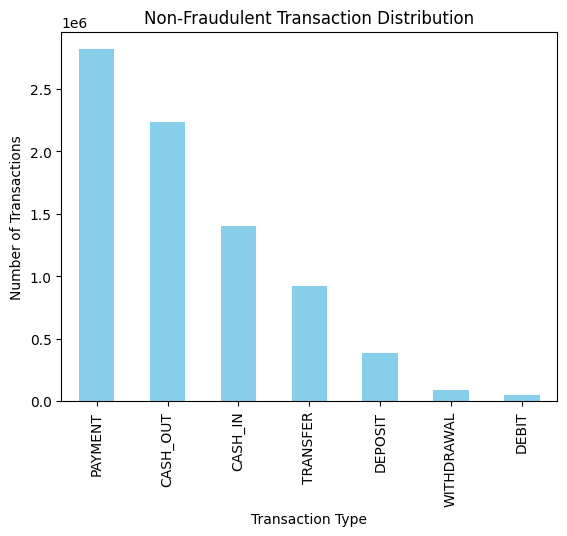

In [18]:
# Visualizing the Distribution of Non-Fraudulent Transaction Types in the original dataset
count_type_fraud = dataset['transactionType'][dataset['isFraud']==0].value_counts()
count_type_fraud.plot(kind='bar', color='skyblue')
plt.title('Non-Fraudulent Transaction Distribution')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')
plt.show()

In [19]:
print(
    f"Pourcentage de PAYMENT non frauduleux : {(len(dataset[dataset['transactionType'] == 'PAYMENT']) / dataset.shape[0]) * 100:.2f} %"
)
print(
    f"Pourcentage de CASH_IN non frauduleux : {(len(dataset[dataset['transactionType'] == 'CASH_IN']) / dataset.shape[0]) * 100:.2f} %"
)
print(
    f"Pourcentage de DEPOSIT non frauduleux : {(len(dataset[dataset['transactionType'] == 'DEPOSIT']) / dataset.shape[0]) * 100:.2f} %"
)
print(
    f"Pourcentage de WITHDRAWAL non frauduleux : {(len(dataset[dataset['transactionType'] == 'WITHDRAWAL']) / dataset.shape[0]) * 100:.2f} %"
)
print(
    f"Pourcentage de DEBIT non frauduleux : {(len(dataset[dataset['transactionType'] == 'DEBIT']) / dataset.shape[0]) * 100:.2f} %"
)
print(
    f"Pourcentage de TRANSFERT non frauduleux : {(dataset[(dataset['transactionType'] == 'TRANSFER') & (dataset['isFraud'] == 0)].shape[0] / dataset.shape[0]) * 100:.2f} %"
)
print(
    f"Pourcentage de CASH_OUT non frauduleux : {(dataset[(dataset['transactionType'] == 'CASH_OUT') & (dataset['isFraud'] == 0)].shape[0] / dataset.shape[0]) * 100:.2f} %"
)

Pourcentage de PAYMENT non frauduleux : 34.87 %
Pourcentage de CASH_IN non frauduleux : 17.31 %
Pourcentage de DEPOSIT non frauduleux : 4.76 %
Pourcentage de WITHDRAWAL non frauduleux : 1.16 %
Pourcentage de DEBIT non frauduleux : 0.58 %
Pourcentage de TRANSFERT non frauduleux : 11.41 %
Pourcentage de CASH_OUT non frauduleux : 27.63 %


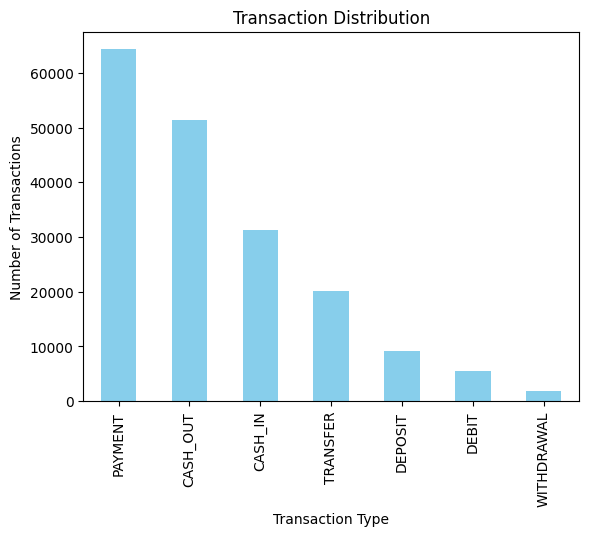

In [20]:
def sample_by_percentage(df, col, distribution, total):
    samples = []
    types = list(distribution.keys())
    n_par_type = {}

    # percentage conversion
    for t, p in distribution.items():
        n_par_type[t] = int(p / 100 * total)


    diff = total - sum(n_par_type.values())
    
    last_type = types[-1]
    n_par_type[last_type] += diff

    
    for t in types:
        tmp_df = df[df[col] == t]
        n = n_par_type[t]
        n = min(n, len(tmp_df))  
        samples.append(tmp_df.sample(n=n, random_state=42))

    return pd.concat(samples, ignore_index=True)

non_fraud_dataset= dataset[dataset['isFraud'] == 0]

N_total = 183731

distribution = {
    'PAYMENT': 35,
    'CASH_OUT': 28,
    'CASH_IN': 17,
    'TRANSFER': 11,
    'DEPOSIT': 5,
    'WITHDRAWAL': 1,
    'DEBIT': 3
}

clean_df_pt2 = sample_by_percentage(non_fraud_dataset, 'transactionType', distribution, N_total)

# Visualizing the distribution of our intermediate non-fraudulent dataset
count_type_fraud = clean_df_pt2['transactionType'].value_counts()
count_type_fraud.plot(kind='bar', color='skyblue')
plt.title('Transaction Distribution')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')
plt.show()

In [21]:
clean_df = pd.concat([clean_df_pt1, clean_df_pt2], ignore_index=True)
clean_df

,transactionType,amount,initiator,oldBalInitiator,newBalInitiator,recipient,oldBalRecipient,newBalRecipient,isFraud
0,TRANSFER,19824.96,4537027967639631,187712.18,167887.22,4875702729424478,8.31,19833.27,1
1,TRANSFER,19847.01,4178224023847746,-452.25,-20299.26,4096920916696293,4011.72,23858.74,1
2,TRANSFER,16973.75,4779013371563747,158601.88,141628.12,4593247015015219,54.33,17028.08,1
3,TRANSFER,21103.99,4479448076398077,261291.46,240187.47,4649550475321678,19.63,21123.63,1
4,TRANSFER,16908.07,4587942659105635,4160.05,4160.05,4863167876028593,66.12,66.12,1
...,...,...,...,...,...,...,...,...,...
367457,DEBIT,8777.88,C2144746091,11099.00,2321.12,C966081920,67673.90,76451.78,0
367458,DEBIT,4177.88,4287247950131709,2087061.28,2082883.40,B15-0002587,0.00,0.00,0
367459,DEBIT,6644.00,C138843372,101226.00,94582.00,C1897712408,59717.52,66361.52,0
367460,DEBIT,10774.11,C936751623,3765.00,0.00,C738516100,242508.40,253282.51,0


###### clean_df is our final dataset. We have managed to balance the number of positive and negative values while ensuring the transposition of the initial dataset distribution to the non-fraudulent part of our new and clean dataset.

###### here we are going to do a bit of feature engineering before training the model  

In [22]:
clean_df.columns

Index(['transactionType', 'amount', 'initiator', 'oldBalInitiator',
       'newBalInitiator', 'recipient', 'oldBalRecipient', 'newBalRecipient',
       'isFraud'],
      dtype='object')

In [23]:
#let's drop initator and recipient since they are IDS and won't really be useful 
reg_df = clean_df.drop(columns=["initiator", "recipient"])
reg_df

,transactionType,amount,oldBalInitiator,newBalInitiator,oldBalRecipient,newBalRecipient,isFraud
0,TRANSFER,19824.96,187712.18,167887.22,8.31,19833.27,1
1,TRANSFER,19847.01,-452.25,-20299.26,4011.72,23858.74,1
2,TRANSFER,16973.75,158601.88,141628.12,54.33,17028.08,1
3,TRANSFER,21103.99,261291.46,240187.47,19.63,21123.63,1
4,TRANSFER,16908.07,4160.05,4160.05,66.12,66.12,1
...,...,...,...,...,...,...,...
367457,DEBIT,8777.88,11099.00,2321.12,67673.90,76451.78,0
367458,DEBIT,4177.88,2087061.28,2082883.40,0.00,0.00,0
367459,DEBIT,6644.00,101226.00,94582.00,59717.52,66361.52,0
367460,DEBIT,10774.11,3765.00,0.00,242508.40,253282.51,0


In [24]:
#Next let's encode the transactionType column so it can be actually useful 
reg_df['transactionType'].unique()

array(['TRANSFER', 'CASH_OUT', 'PAYMENT', 'CASH_IN', 'DEPOSIT',
       'WITHDRAWAL', 'DEBIT'], dtype=object)

In [25]:
mapping = {
"CASH_IN"    : 0,
"CASH_OUT"    :1,
"DEBIT"       : 2,
"DEPOSIT"      : 3,
"PAYMENT"      : 4,
"TRANSFER"     : 5,
"WITHDRAWAL"   :6
}

reg_df["Transaction_encoded"] = reg_df["transactionType"].map(mapping)
reg_df = reg_df.drop(columns=["transactionType"])

reg_df


,amount,oldBalInitiator,newBalInitiator,oldBalRecipient,newBalRecipient,isFraud,Transaction_encoded
0,19824.96,187712.18,167887.22,8.31,19833.27,1,5
1,19847.01,-452.25,-20299.26,4011.72,23858.74,1,5
2,16973.75,158601.88,141628.12,54.33,17028.08,1,5
3,21103.99,261291.46,240187.47,19.63,21123.63,1,5
4,16908.07,4160.05,4160.05,66.12,66.12,1,5
...,...,...,...,...,...,...,...
367457,8777.88,11099.00,2321.12,67673.90,76451.78,0,2
367458,4177.88,2087061.28,2082883.40,0.00,0.00,0,2
367459,6644.00,101226.00,94582.00,59717.52,66361.52,0,2
367460,10774.11,3765.00,0.00,242508.40,253282.51,0,2


In [26]:
#Now let's add three new features 

#The first one will let's us the diffrence of money after the transaction
reg_df['balance_change_initiator'] = reg_df['oldBalInitiator'] - reg_df['newBalInitiator']

#the second one help us understand better the status of the account 
reg_df['balance_change_recipient'] = reg_df['newBalRecipient'] - reg_df['oldBalRecipient']

#Lastly since large transaction can often be fraud 
reg_df['large_amount_type'] = reg_df.groupby('Transaction_encoded')['amount'].transform(
    lambda x: (x > x.quantile(0.95)).astype(int)
)

In [27]:
# We will also add this feature 
#Tell us if the ammount of the receiver increase by a lot
reg_df['recipient_large_increase'] = (
    reg_df['balance_change_recipient'] >
    reg_df['balance_change_recipient'].quantile(0.95)
).astype(int)

# now let's drop those column 
reg_df = reg_df.drop(columns=['oldBalRecipient', 'newBalRecipient'])

#Dataset for classification
reg_df

,amount,oldBalInitiator,newBalInitiator,isFraud,Transaction_encoded,balance_change_initiator,balance_change_recipient,large_amount_type,recipient_large_increase
0,19824.96,187712.18,167887.22,1,5,19824.96,19824.96,0,0
1,19847.01,-452.25,-20299.26,1,5,19847.01,19847.02,0,0
2,16973.75,158601.88,141628.12,1,5,16973.76,16973.75,0,0
3,21103.99,261291.46,240187.47,1,5,21103.99,21104.00,0,0
4,16908.07,4160.05,4160.05,1,5,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...
367457,8777.88,11099.00,2321.12,0,2,8777.88,8777.88,0,0
367458,4177.88,2087061.28,2082883.40,0,2,4177.88,0.00,0,0
367459,6644.00,101226.00,94582.00,0,2,6644.00,6644.00,0,0
367460,10774.11,3765.00,0.00,0,2,3765.00,10774.11,0,0


In [28]:
#variable selection 
X = reg_df.drop('isFraud', axis=1)
y = reg_df['isFraud']

In [29]:
#Splitting the dataset 
from sklearn.model_selection import train_test_split
X_train, X_test,y_train, y_test = train_test_split(X,y, 
                                        test_size=0.25, 
                                        random_state=1)

y_train

149779    1
101304    1
269136    0
307222    0
202275    0
         ..
117583    1
73349     1
312201    0
267336    0
128037    1
Name: isFraud, Length: 275596, dtype: int64

In [30]:
#model trainning 
from sklearn.tree import DecisionTreeClassifier
dtree=DecisionTreeClassifier(criterion='entropy',random_state=0)
dtree.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

###### I used a decision tree because it is easy to intreprate, which is important in fraud detection where model decisions must be explainable. It also handles nonlinear relations between variables and requires less preprocessing. This makes it a good base model for understanding feature behavior and interpreting models in the dataset.

In [31]:
#model evaluation 
y_dtree=dtree.predict(X_test)
comparison_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_dtree
})

print(comparison_df.head(20))

    actual  predicted
0        0          0
1        1          1
2        1          1
3        0          0
4        1          1
5        1          1
6        1          1
7        1          0
8        1          1
9        0          0
10       1          1
11       1          0
12       0          0
13       0          0
14       1          1
15       0          0
16       0          0
17       1          1
18       0          0
19       1          1


In [41]:
from sklearn.metrics import (accuracy_score,
    f1_score, 
    precision_score, 
    recall_score
)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_xgb))
print("F1 Score:", f1_score(y_test, y_dtree))
print("Precision:", precision_score(y_test, y_dtree))
print("Recall:", recall_score(y_test, y_dtree))

Accuracy: 0.9753771798053686
F1 Score: 0.9546375580103275
Precision: 0.9553036084160035
Recall: 0.9539724357159964


###### As we can see has a 95% in recall and precison, same for the f1 score, which are all important metric when it come to fraud prediction, those result show that the model is really decent when it comes to fraud prediction 

In [33]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

###### After establishing this baseline, I tested XGBoost because it is a more advanced ensemble method known to perform exceptionally well on tabular data.

In [34]:
#Model evaluation
y_xgb = xgb_model.predict(X_test)
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_xgb
})
print(comparison.head(20))

        Actual  Predicted
294342       0          0
97630        1          1
59354        1          1
238571       0          0
147218       1          1
95703        1          1
141925       1          1
89383        1          1
159337       1          1
290885       0          0
62197        1          1
65589        1          1
217774       0          0
341963       0          0
114317       1          1
333630       0          0
202262       0          0
170774       1          1
242299       0          0
163147       1          1


In [40]:
#Metrics
from sklearn.metrics import (accuracy_score,
    f1_score, 
    precision_score, 
    recall_score)

print("Accuracy:", accuracy_score(y_test, y_xgb))
print("F1 Score:", f1_score(y_test, y_xgb))
print("Precision:", precision_score(y_test, y_xgb))
print("Recall:", recall_score(y_test, y_xgb))

Accuracy: 0.9753771798053686
F1 Score: 0.9759458942129777
Precision: 0.9538340019538963
Recall: 0.99910731781663


###### the xgboost model has better accuracy and f1 score but doen't really do a lot more than the decison tree model. so my first intution of using the DecisionTree as a  base model was right since the the metrics don't change much  

In [39]:
#Now we are going to look at the feature that matter the most here 
booster = xgb_model.get_booster()
booster.feature_names = [str(f) for f in X_train.columns]

importances = booster.get_score(importance_type='gain')
feat_imp_df = pd.DataFrame({
    'feature': list(importances.keys()),
    'importance': list(importances.values())
}).sort_values(by='importance', ascending=False)

print(feat_imp_df)


                    feature   importance
3       Transaction_encoded  3537.050537
4  balance_change_initiator   410.055786
7  recipient_large_increase   335.557373
5  balance_change_recipient   224.516785
0                    amount    83.961494
2           newBalInitiator    67.860527
1           oldBalInitiator    37.221481
6         large_amount_type    20.551752


###### Feature engineering was highly successful.The new variables gave meaningful information that the model could not capture from the raw features alone. Transaction_encoded is by far the strongest predictor,balance_change_initiator, recipient_large_increase, and balance_change_recipient are also among the top contributors,These features directly measure abnormal balance variations, which are classic fraud signals